Text to image Generation using stable Duffsion and Diffusers


In [1]:
! pip install diffusers transformers accelerate

In [2]:
from diffusers import StableDiffusionXLPipeline
import torch
import matplotlib.pyplot as plt
import gradio as gr

In [3]:
! pip show torch

Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.13/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision


In [11]:
model_id1="dreamlike-art/dreamlike-diffusion-1.0"
model_id2="stabilityai/stable-diffusion-xl-base-1.0"
# model_id2="black-forest-labs/FLUX.1-dev"

pipe=StableDiffusionPipeline.from_pretrained(model_id2,torch_dtype=torch.float16,use_auth_token=True)
pipe=pipe.to("cuda")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Keyword arguments {'use_auth_token': True} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [12]:
prompt="""A girl is playing with gun with a left hand
and other main fer"""

In [13]:
image=pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

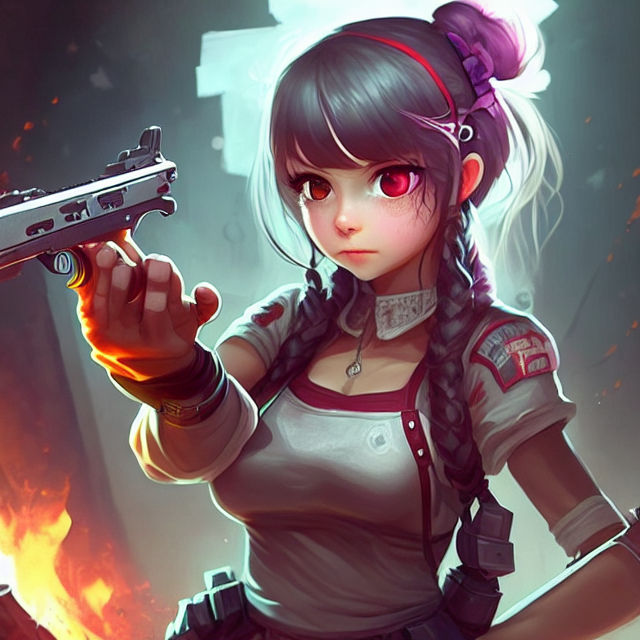

In [14]:
image

[PROMPT] A girl is playing with gun with a left hand
and other main fer


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

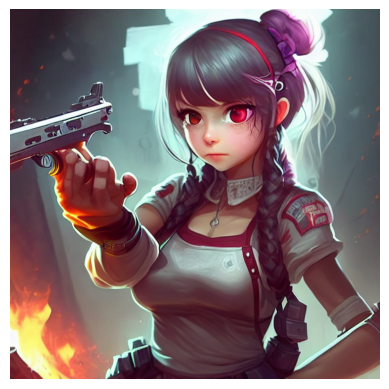

In [15]:
print("[PROMPT]",prompt)
plt.imshow(image)
plt.axis("off")

In [16]:
prompt2="""A girl on chair and she is reading the book"""
image=pipe(prompt2).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

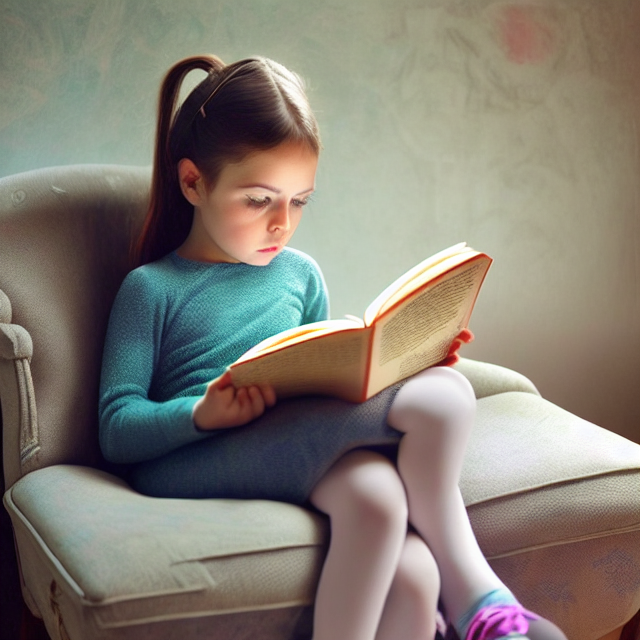

In [17]:
image

[PROMPT] A girl on chair and she is reading the book


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

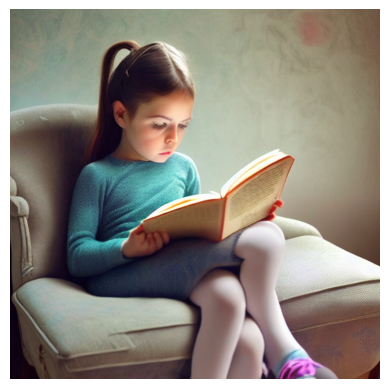

In [18]:
print("[PROMPT]",prompt2)
plt.imshow(image)
plt.axis("off")

In [28]:
def generate_image(pip,prompt,params):
  img=pip(prompt,**params).images
  num_images=len(img)
  if num_images>1:
    fig, ax=plt.subplots(nrows=1,ncols=num_images)
    for i in range(num_images):
      ax[i].imshow(img[i])
      ax[i].axis("off")
  else:
    flg=plt.figure()
    plt.imshow(img[0])
    plt.axis("off")
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [22]:
prompt="A man riding the bike"
params={}

  0%|          | 0/50 [00:00<?, ?it/s]

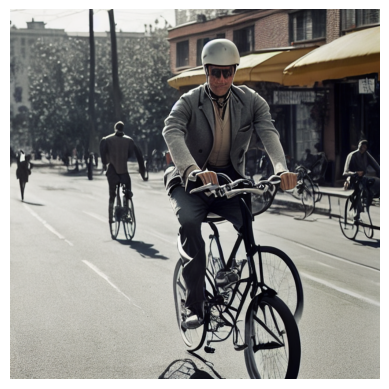

In [23]:
generate_image(pipe,prompt,params)

  0%|          | 0/50 [00:00<?, ?it/s]

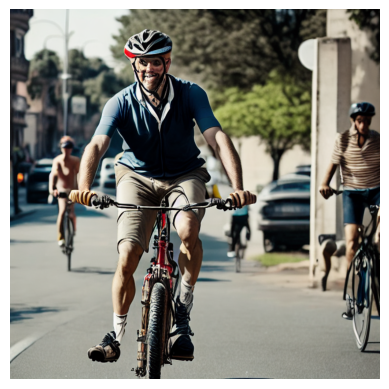

In [24]:
params={'num_inference_step':100}
generate_image(pipe,prompt,params)

  0%|          | 0/50 [00:00<?, ?it/s]

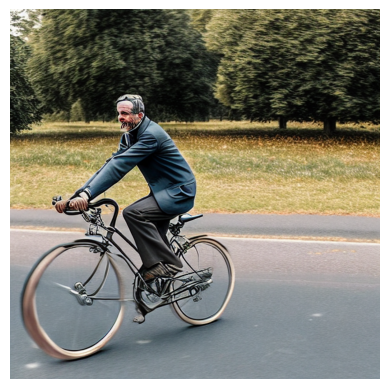

In [25]:
parms={'num_inference_steps':100, 'width':513,'height':int(1.5*630)}
generate_image(pipe,prompt,params)

  0%|          | 0/100 [00:00<?, ?it/s]

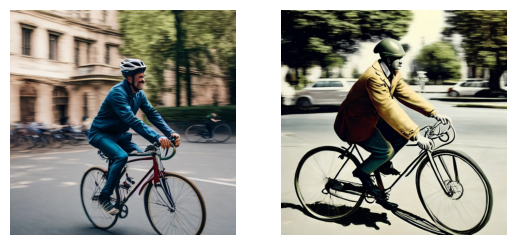

In [29]:
params={'num_inference_steps': 100, 'num_images_per_prompt': 2}
generate_image(pipe,prompt,params)

  0%|          | 0/100 [00:00<?, ?it/s]

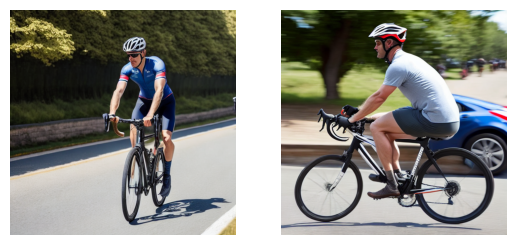

In [30]:
params = {'num_inference_steps': 100, 'num_images_per_prompt': 2, 'negative_prompt': 'ugly, distorted,  low quality'}
generate_image(pipe,prompt,params)

# Other Different Model for text to image


In [1]:
import torch
from diffusers import StableDiffusionXLPipeline

model_id = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionXLPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)

pipe = pipe.to("cuda")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [2]:
prompt="""A highly realistic photograph of a young Indian man standing on a rooftop in Hyderabad during golden hour, wearing a simple dark blue casual shirt and jeans, looking naturally toward the city skyline. Modern buildings in the background, warm sunlight falling softly across his face, realistic skin texture, natural hair, subtle facial expression, detailed clothing fabric, slight wind movement, atmospheric depth, soft shadows, cinematic composition, shallow depth of field, shot on a professional full-frame camera, 85mm lens, natural colors, photorealistic, ultra-detailed, realistic lighting, 8K photography."""

In [3]:
image=pipe(prompt).images[0]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (114 > 77). Running this sequence through the model will result in indexing errors
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CLIPTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['cinematic composition , shallow depth of field , shot on a professional full - frame camera , 8 5 mm lens , natural colors , photorealistic , ultra - detailed , realistic lighting , 8 k photography .']
[transformers] Token indices sequence length is longer than the specified maximum 

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


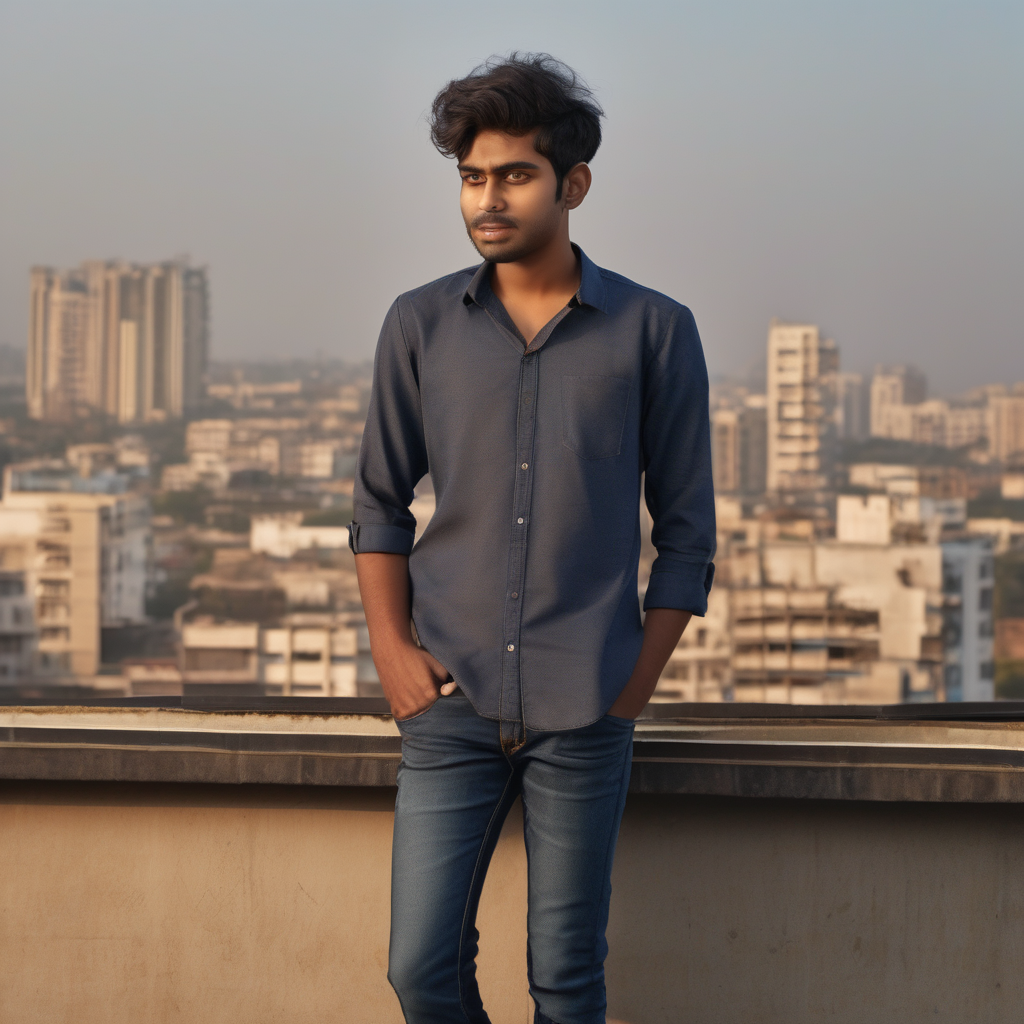

In [4]:
image

In [5]:
prompt2=""" A highly realistic cinematic portrait of a stylish South Indian man wearing a perfectly tailored black formal suit jacket over a black shirt, with the shirt slightly unbuttoned at the collar. He has thick, naturally wavy black hair, a confident and serious expression, and elegant black sunglasses. He stands with a relaxed but powerful posture, one hand casually in his trouser pocket. Dark luxury background with subtle blurred lights, dramatic low-key cinematic lighting, soft highlights on the face and suit, realistic skin texture, natural facial details, detailed black fabric and suit texture, sharp focus on the subject, shallow depth of field, sophisticated gangster-inspired fashion, premium film photography, 85mm lens, photorealistic, ultra-detailed, natural colors, cinematic atmosphere, high resolution.
"""

In [6]:
image=pipe(prompt2).images[0]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['background with subtle blurred lights , dramatic low - key cinematic lighting , soft highlights on the face and suit , realistic skin texture , natural facial details , detailed black fabric and suit texture , sharp focus on the subject , shallow depth of field , sophisticated gangster - inspired fashion , premium film photography , 8 5 mm lens , photorealistic , ultra - detailed , natural colors , cinematic atmosphere , high resolution .']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['background with subtle blurred lights , dramatic low - key cinematic lighting , soft highlights on the face and suit , realistic skin texture , natural facial details , detailed black fabric and suit texture , sharp focus on the subject , shallow depth of field , sophisticated gangster - inspired fashion , premium film photography , 8 5 mm len

  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


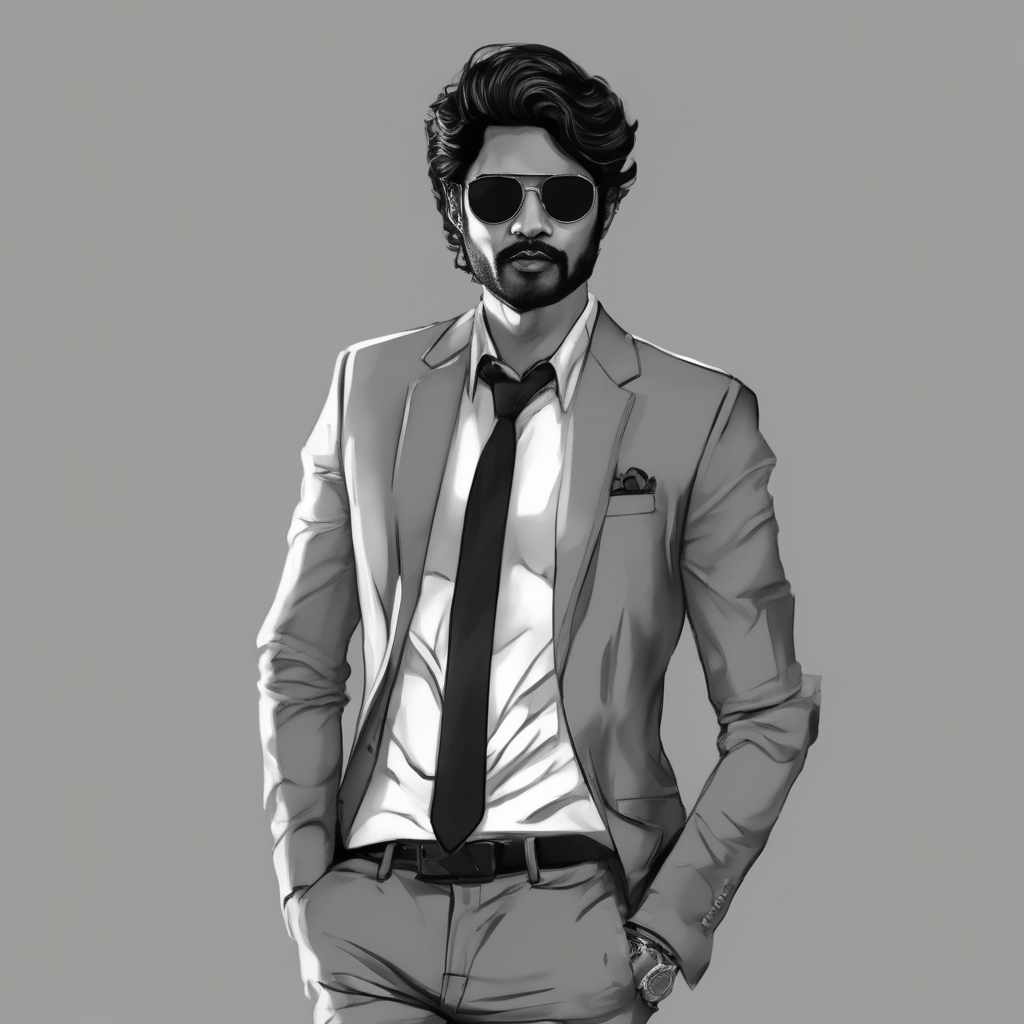

In [7]:
image

# Tongyi-MAI/Z-Image


In [8]:
!pip install -U diffusers transformers accelerate

In [9]:
import torch
from diffusers import ZImagePipeline

model_id = "Tongyi-MAI/Z-Image"

pipe = ZImagePipeline.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=False
)

pipe = pipe.to("cuda")


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 30.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 1.81 MiB is free. Including non-PyTorch memory, this process has 14.56 GiB memory in use. Of the allocated memory 14.10 GiB is allocated by PyTorch, and 334.07 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [10]:
prompt = """
A highly realistic cinematic portrait of a stylish South Indian man
wearing a perfectly tailored black formal suit jacket over a black shirt,
with the shirt slightly unbuttoned at the collar. Thick naturally wavy
black hair, confident serious expression, elegant black sunglasses,
relaxed but powerful posture, one hand casually in his trouser pocket.
Luxury dark background with subtle blurred lights, dramatic low-key
cinematic lighting, realistic skin texture, detailed black fabric,
sharp focus, shallow depth of field, premium film photography,
85mm lens, photorealistic, ultra-detailed, natural colors.
"""

image = pipe(
    prompt=prompt,
    height=1024,
    width=1024,
    num_inference_steps=35,
    guidance_scale=4.0
).images[0]

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 1.81 MiB is free. Including non-PyTorch memory, this process has 14.56 GiB memory in use. Of the allocated memory 14.12 GiB is allocated by PyTorch, and 316.56 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
image